# Virtual Population Inference Tutorial

**Certara IQ Python Client**  
*Calibrating a cancer immunity model to KEYNOTE-001 NSCLC clinical data*

## Background and Overview

This tutorial demonstrates **virtual population (VPop) inference** — a workflow that calibrates a mechanistic model to produce a population of virtual patients whose simulated outcomes statistically match clinical observations. The methodology follows the two-stage Bayesian approach of Allen et al. (2016, PMID: 27069777).

### Model

The tutorial uses the **minimal Cancer Immunity Cycle (mCIC)** model with anti-PD1 treatment, described in Lazarou et al. (2020, *Clin Pharmacol Ther*, 107(4), 858–870, doi: 10.1002/cpt.1786). The model represents the interaction between tumor cells, cytotoxic CD8+ T cells, and antigen-presenting cells (APCs/dendritic cells) in the tumor microenvironment (TME).

### Calibration Data

<font color="red">Successful calibration of the VPop parameter set must satisfy three types of constraints:</font> ~~The VPop must simultaneously satisfy three types of constraints:~~

1. **Biological plausibility**: Baseline TME composition (CD8+ T cell and dendritic cell percentages) and initial tumor volume must fall within ranges observed in the [Immune Landscape of Cancer](https://pubmed.ncbi.nlm.nih.gov/29628290/) (PMID: 29628290) for NSCLC.
2. **Clinical outcome matching**: When treated with Pembrolizumab 10 mg/kg Q3W, the distribution of percent change in sum of longest dimensions (%SLD) from baseline at day 400 must be statistically indistinguishable from the KEYNOTE-001 trial (PMID: 27117531).
3. **Untreated disease progression**: All virtual patients must exhibit progressive disease (%SLD increase > 20%) when left untreated.
<font color ="red">Virtual population constraints for this example are determined by the disease and available data. All three types of constraints can be customized for any specific model, indication, and data.</font>

### Two-Stage Inference Algorithm

The `abm.virtual_population()` function implements inference in two stages:

| Stage | Name | Purpose |
|-------|------|---------|
| 1 | Plausible Patient Filtering | A machine learning classifier (ClassifierSurrogate) screens large samples from prior distributions, retaining only subjects satisfying plausibility bounds.<font color = "red"> <br>This enforces Constraint 1 and 3 above</font>|
| 2 | Final Population Sampling | Within the plausible population, subjects are resampled with optimized inclusion probabilities to minimize the Kolmogorov-Smirnov (KS) distance from clinical outcome distributions. <font color = "red"> <br>This enforces Constraints 2 above</font>|

### Notebook Structure

| Section | Content |
|---------|---------|
| 1. Setup | <font color = "red"> Import Python modules and set definition for statistical quantiles </font> ~~Imports~~|
| 2. Explore the Clinical Data | Load and visualize parameter table, KEYNOTE-001 data, and TME composition data |
| 3. Build Inference Inputs | Assemble the distributions tables that drive Stage 1 and Stage 2 |
| 4. Run Virtual Population Inference | Execute `abm.virtual_population()` |
| 5. Goodness-of-Fit Evaluation | KS tests, RECIST frequencies, and waterfall plot comparisons |
| 6. Full Time-Course Re-simulation | Simulate VPop trajectories over the full 500-day period |
| 7. Export VPop for IQ Design | Reformat and save the VPop for use in IQ Design workflows |

## 1. Setup

Import the Certara IQ Python client (`abm`) and standard scientific Python libraries. The `plotnine` package provides the ggplot2-style plotting API used throughout this notebook.

In [1]:
import abm
from abm import simulate, virtual_population

import plotnine as p9
import pandas as pd
import numpy as np
import math
import time
from scipy.stats import ks_2samp, chisquare
from typing import Sequence

# Decile quantile levels used for histogram distributions
qs = [0.1 * i for i in range(11)]

## 2. Explore the Clinical Data

Before running inference, we load and inspect the three input datasets that drive the calibration:

1. The parameter table (defines which model parameters vary across virtual patients <font color = "red"> and sets plausible parameter ranges - informed by literature or prior parameter estimation</font>)
2. The KEYNOTE-001 tumor response waterfall data (the efficacy target distribution)
3. The NSCLC TME composition data (the biomarker plausibility bounds)

### 2.1 Parameter Table

The parameter table defines the prior <font color = "red"> distribution </font>sampling space for the virtual population. The required columns are `parameter`, `value`, `unit`, `is_fit`, `lower_bound`, `upper_bound`, `prior_distribution`, `location`, and `scale`. Any additional columns — such as `group` here — are **label columns** that the client uses for row matching across tables, but are not interpreted in any special way by the VPop algorithm itself.

| Column | Type | Role |
|--------|------|------|
| `is_fit` | Required | `True` for parameters that vary across virtual patients; `False` for parameters fixed at a shared value for all subjects. |
| `lower_bound` / `upper_bound` | Required | Biologically plausible bounds; Stage 1 filters candidate patients to this range. |
| `prior_distribution` | Required | Sampling distribution for `is_fit = True` parameters. `uniform` samples uniformly within bounds; `location` and `scale` are used by other distribution types. |
| `group` | **Label column** (user-defined) | Matches parameter rows to simulation scenarios. The `*` wildcard matches any group value. This tutorial defines two groups — `treated` (Pembrolizumab 10 mg/kg Q3W) and `untreated` (control) — which share all parameters except `AMT` (dose amount). Any column name could be used here; `group` has no special meaning to the <font color = "red"> software</font> ~~client~~. |

The five free parameters (`is_fit = True`) are: initial tumor volume (`V0`), tumor growth rate (`mu`), maximum CD8+ T cell fraction (`Tc_max`), maximum APC fraction (`APC_max`), and T cell kill rate (`kkill`).

In [2]:
parameter_table = pd.read_csv('inputs/parameters.csv')
display(parameter_table)

,group,parameter,value,unit,is_fit,prior_distribution,lower_bound,upper_bound,location,scale
0,treated,AMT,10.000000,mg * kg^-1,False,uniform,0.0000,10.00,NaN,NaN
1,untreated,AMT,0.000000,mg * kg^-1,False,uniform,0.0000,10.00,NaN,NaN
2,*,V0,5307.113480,mm^3,True,uniform,50.0000,20000.00,NaN,NaN
3,*,mu,0.036388,1/d,True,uniform,0.0010,0.10,NaN,NaN
4,*,Tc_max,3.854902,1,True,uniform,0.8300,6.43,NaN,NaN
5,*,APC_max,0.915453,1,True,uniform,0.0001,5.00,NaN,NaN
6,*,kkill,0.904284,1/d,True,uniform,0.0001,0.90,NaN,NaN


### 2.2 KEYNOTE-001 Tumor Response Data

The KEYNOTE-001 trial (PMID: 27117531) enrolled NSCLC patients treated with Pembrolizumab 10 mg/kg Q3W. We use the digitized waterfall plot of percent change in sum of longest dimensions (%SLD) from baseline as the target efficacy distribution.

**Simulation timing convention**: The mCIC model includes a 100-day pre-treatment warmup period representing untreated tumor growth before the clinical baseline. Simulation time is therefore offset by +100 days relative to clinical time:

- Simulation day 100 = clinical baseline
- Simulation day 500 = clinical day 400 (the KEYNOTE-001 assessment endpoint)

The loaded data is formatted with `time = 500` (simulation day) and `group = "treated"` to align with the virtual population simulation outputs.

In [3]:
sld_changes = (
    pd.read_csv('inputs/KEYNOTE001_waterfall_plot.csv')
    .rename(columns={"CHANGE": "measurement"})
    .drop(columns='ID')
    .assign(
        output='SLD_percent_change_from_baseline',
        time=500,
        time_unit='d',
        measurement_unit='1',
        group='treated'
    )
)

print(f"{len(sld_changes)} patients")
sld_changes.head()

118 patients


,measurement,output,time,time_unit,measurement_unit,group
0,99.655766,SLD_percent_change_from_baseline,500,d,1,treated
1,85.542169,SLD_percent_change_from_baseline,500,d,1,treated
2,70.740103,SLD_percent_change_from_baseline,500,d,1,treated
3,48.709122,SLD_percent_change_from_baseline,500,d,1,treated
4,47.676420,SLD_percent_change_from_baseline,500,d,1,treated


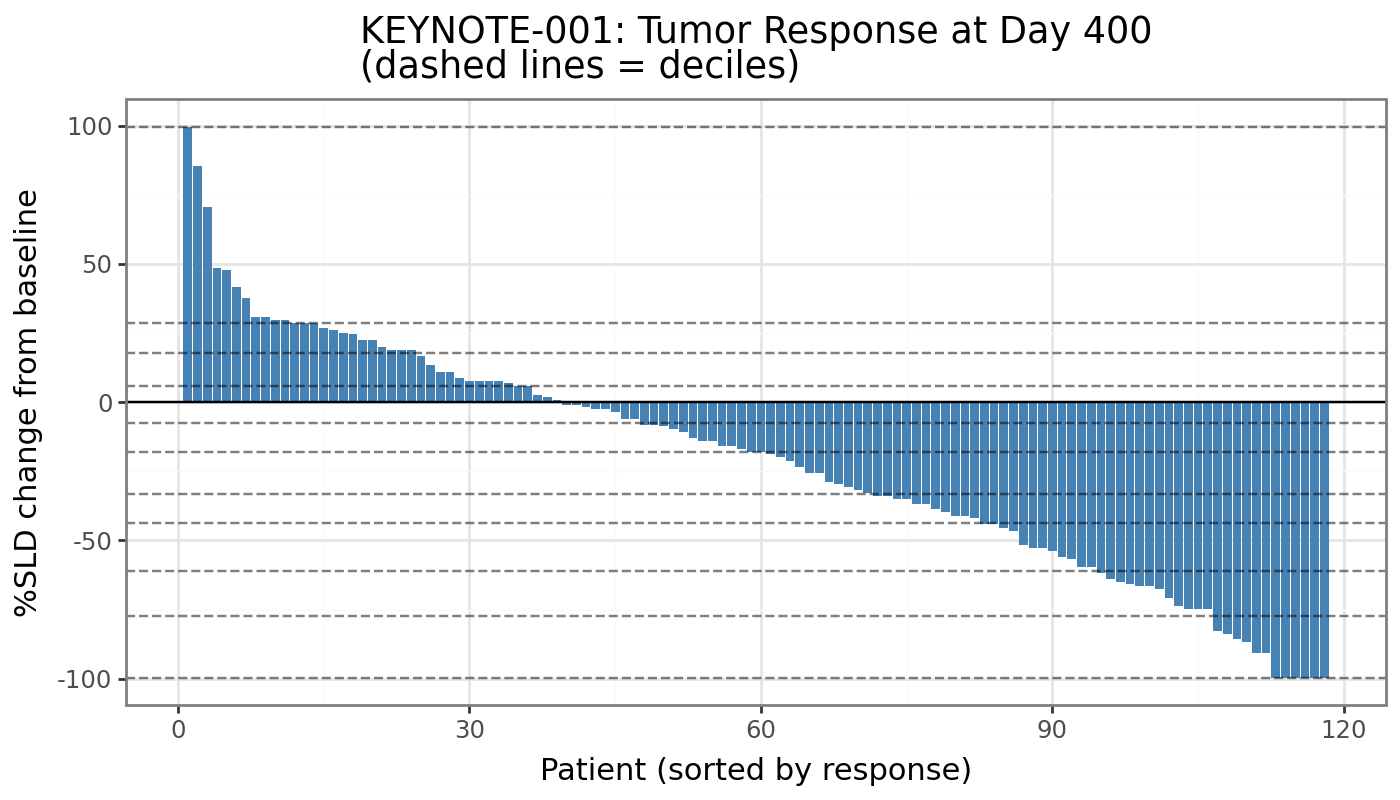

In [4]:
(
    p9.ggplot(data=sld_changes)
    + p9.geom_col(
        mapping=p9.aes(x='measurement.rank(method="first", ascending=False)', y='measurement'),
        fill='steelblue'
    )
    + p9.geom_hline(
        yintercept=np.quantile(sld_changes.measurement, q=[0.1*i for i in range(11)]),
        linetype='dashed', color='black', alpha=0.5
    )
    + p9.geom_hline(yintercept=0, color='black')
    + p9.labs(
        x='Patient (sorted by response)',
        y='%SLD change from baseline',
        title='KEYNOTE-001: Tumor Response at Day 400\n(dashed lines = deciles)'
    )
    + p9.theme_bw()
    + p9.theme(figure_size=[7, 4])
)

### 2.3 Tumor Microenvironment (TME) Composition Data

The Immune Landscape of Cancer (PMID: 29628290) characterizes the immune cell composition of NSCLC tumors. We use two quantities from this dataset:

| Column | Model variable | Biological meaning |
|--------|---------------|-------------------|
| `Percent_CC` | `Tc_tme` | Percentage of cytotoxic CD8+ T cells in the TME |
| `Percent_DC` | `APC_tme` | Percentage of dendritic cells in the TME |

These distributions constrain the initial immune state of virtual patients via the `Tc_max` and `APC_max` parameters. The data is assigned to simulation time 100 (the warmup baseline) with `group = "untreated"`.

In [5]:
TME_composition = (
    pd.read_csv("inputs/NSCLC_TME_composition.csv")
    .melt(var_name='output', value_name='measurement')
    .assign(time=100., time_unit='d', measurement_unit='1', group='untreated')
)

print(f"{len(TME_composition)} observations across {TME_composition['output'].nunique()} cell types")
TME_composition.head()

2312 observations across 2 cell types


,output,measurement,time,time_unit,measurement_unit,group
0,Percent_CC,6.012864,100.0,d,1,untreated
1,Percent_CC,3.934277,100.0,d,1,untreated
2,Percent_CC,2.687790,100.0,d,1,untreated
3,Percent_CC,4.933115,100.0,d,1,untreated
4,Percent_CC,4.602951,100.0,d,1,untreated


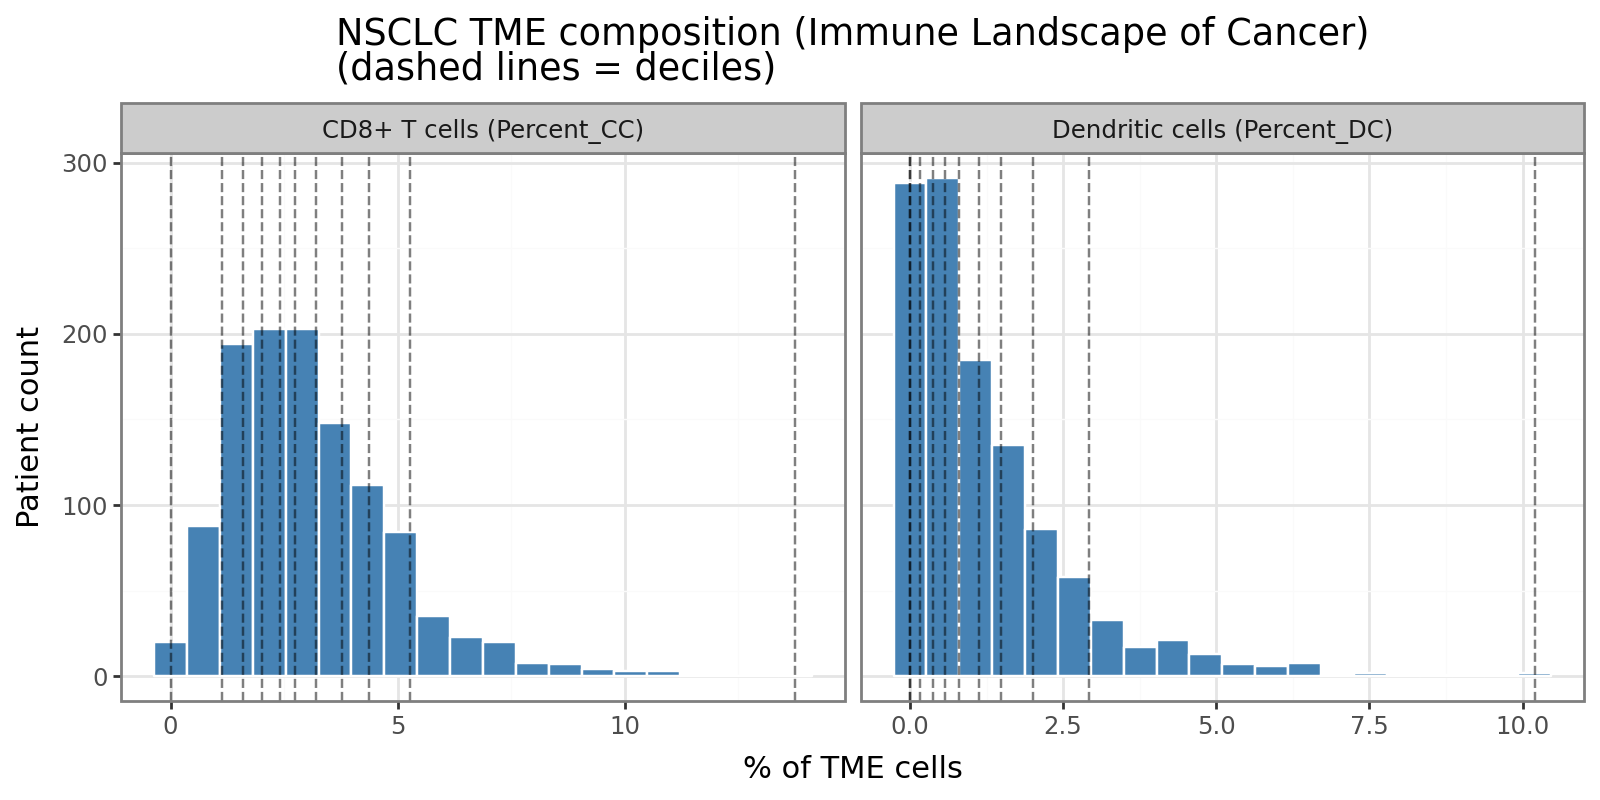

In [6]:
(
    p9.ggplot()
    + p9.stat_bin(
        data=TME_composition,
        mapping=p9.aes(x='measurement'),
        bins=20, fill='steelblue', color='white'
    )
    + p9.geom_vline(
        data=TME_composition.groupby('output').measurement.quantile(q=qs).reset_index(),
        mapping=p9.aes(xintercept='measurement'),
        linetype='dashed', color='black', alpha=0.5
    )
    + p9.facet_wrap('~ output', scales='free_x', 
                    labeller=lambda y: {'Percent_CC': 'CD8+ T cells (Percent_CC)', 
                                        'Percent_DC': 'Dendritic cells (Percent_DC)'}[y]
    )
    + p9.labs(
        x='% of TME cells',
        y='Patient count',
        title='NSCLC TME composition (Immune Landscape of Cancer)\n(dashed lines = deciles)'
    )
    + p9.theme_bw()
    + p9.theme(figure_size=[8, 4])
)

## 3. Build Inference Inputs

The `abm.virtual_population()` function accepts two separate distributions tables:

- **`proposal_distributions`** (Stage 1): Used to train the ClassifierSurrogate and define which candidate subjects are biologically plausible. This combines empirical clinical distributions *and* hard bounds on physiological quantities.
- **`distributions`** (Stage 2): Used to sample the final virtual population. Contains only the empirical clinical outcome distributions the VPop must reproduce.

This section constructs both tables from the clinical datasets loaded above.

### 3.1 Converting Data to HistogramDistributions

The `virtual_population()` function represents all constraints as `HistogramDistribution` objects. Each distribution specifies the expected statistical shape of a model output at a given simulation time via quantile-based bin edges and equal-probability bins.

The helper function below takes a measurements DataFrame and a set of quantile levels, and returns a distributions table in the format required by `abm.virtual_population()`.

In [7]:
def get_distributions(data: pd.DataFrame, quantiles: Sequence[float]) -> pd.DataFrame:
    """Convert a measurements DataFrame into an abm distributions table.

    Each unique combination of (group, output, time, time_unit, measurement_unit)
    becomes one HistogramDistribution row. Bin edges are set at the specified
    quantile levels of the observed measurements.

    Parameters
    ----------
    data:
        DataFrame with required columns: output, time, time_unit,
        measurement, measurement_unit. Any additional columns are treated as
        label columns and preserved.
    quantiles:
        Sequence of probability levels (0–1) for bin edges, e.g. deciles.
    """
    required_cols = {'output', 'time', 'time_unit', 'measurement', 'measurement_unit'}
    missing_cols = sorted(required_cols - set(data.columns))
    if missing_cols:
        raise ValueError(f"Missing required columns: {', '.join(missing_cols)}")

    grouping_cols = [col for col in data.columns if col not in required_cols]

    def get_bins(df: pd.DataFrame):
        return pd.Series({
            'bin_edges': df.measurement.quantile(q=quantiles).tolist(),
            'bin_probabilities': [1. / (len(quantiles) - 1) for _ in quantiles[1:]]
        })

    result = (
        data
        .groupby(grouping_cols + ['output', 'time', 'time_unit', 'measurement_unit'])
        .apply(get_bins, include_groups=False)
        .reset_index()
        .rename(columns={'measurement_unit': 'distribution_unit', 'output': 'target'})
        .assign(distribution='HistogramDistribution', smoothness=0.)
    )

    col_order = grouping_cols + [
        'target', 'distribution', 'distribution_unit',
        'bin_edges', 'bin_probabilities', 'time', 'time_unit', 'smoothness'
    ]
    return result[col_order]

### 3.2 Stage 2 Distributions (Clinical Outcome Targets)

The Stage 2 distributions encode the empirical distributions the final virtual population must reproduce:

- `SLD_percent_change_from_baseline` at simulation day 500 (`group = "treated"`) — from KEYNOTE-001
- `Percent_CC` and `Percent_DC` at simulation day 100 (`group = "untreated"`) — from the Immune Landscape of Cancer

These are the distributions that the `ExpectedPopulation` sampling algorithm optimizes against in Stage 2.

In [8]:
measurements = pd.concat([sld_changes, TME_composition], ignore_index=True)

final_distributions = get_distributions(measurements, quantiles=qs)
final_distributions

,group,target,distribution,distribution_unit,bin_edges,bin_probabilities,time,time_unit,smoothness
0,treated,SLD_percent_change_from_baseline,HistogramDistribution,1,"[-99.65576592, -77.246127366, -60.963855421999...","[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, ...",500.0,d,0.0
1,untreated,Percent_CC,HistogramDistribution,1,"[0.0, 1.124170551, 1.584956714, 2.012934591, 2...","[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, ...",100.0,d,0.0
2,untreated,Percent_DC,HistogramDistribution,1,"[0.0, 0.003076308, 0.171524754, 0.368875037000...","[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, ...",100.0,d,0.0


### 3.3 Stage 1 Bounds (Biological Plausibility Constraints)

Stage 1 additionally constrains virtual patients to satisfy hard physiological bounds. These are represented as two-bin HistogramDistributions (a uniform distribution between a lower and upper limit), meaning any value outside the bounds has zero probability.

We define bounds for:

| Constraint | Quantity | Bound | Rationale |
|------------|---------|-------|-----------|
| Untreated progression | `SLD_percent_change_from_baseline` at day 500, untreated | > 20% | All subjects must exhibit progressive disease without treatment |
| Tumor size | `TME` at day 100 | 100–20,000 mm³ | Clinically observed baseline tumor volume range |
| Cell percentages | `Percent_CC`, `Percent_DC` at days 165, 230, 292 | 0–max observed | Constrain immune cell dynamics within observed physiological range |

The helper function below constructs a single-row bounds distributions entry.

In [9]:
def bound_target(target, time, lower_bound, upper_bound, time_unit='d', group='untreated'):
    """Create a two-bin HistogramDistribution representing hard physiological bounds.

    The resulting distribution assigns uniform probability to values in
    [lower_bound, upper_bound] and zero probability outside.

    Parameters
    ----------
    target : str
        Model output name.
    time : float
        Simulation time at which to evaluate the constraint.
    lower_bound, upper_bound : float
        Acceptable range for the target quantity.
    time_unit : str
        Unit for the time argument.
    group : str
        Simulation group label.
    """
    unit_map = {
        'SLD_percent_change_from_baseline': '1',
        'Percent_CC': '1',
        'Percent_DC': '1',
        'TME': 'mm^3',
    }
    if target not in unit_map:
        raise ValueError(f"Unrecognized target {target!r}.")

    return pd.DataFrame([{
        'group': group,
        'target': target,
        'distribution': 'HistogramDistribution',
        'distribution_unit': unit_map[target],
        'bin_edges': [lower_bound, upper_bound],
        'bin_probabilities': [1.],
        'time': time,
        'time_unit': time_unit,
        'smoothness': 0.
    }])

Build each bounds constraint and collect them in a dictionary before concatenating.

In [10]:
bounds_distributions = {}

# Untreated subjects must show progressive disease (%SLD > 20%) by day 500
bounds_distributions['sld_untreated'] = bound_target(
    'SLD_percent_change_from_baseline', time=500., lower_bound=20., upper_bound=1e9
)

# Baseline tumor volume must be in clinically observed range at day 100
bounds_distributions['tme'] = bound_target(
    'TME', time=100., lower_bound=100., upper_bound=20_000.
)

# CD8+ T cell and dendritic cell fractions must remain within the observed
# maximum across several post-baseline time points
max_obs_comps = {
    output: TME_composition.query(f'output == {output!r}').measurement.max().item()
    for output in ['Percent_CC', 'Percent_DC']
}

for output, upper_bound in max_obs_comps.items():
    for t in [165., 230., 292.]:
        bounds_distributions[f'{output}_{t}d'] = bound_target(
            output, time=t, lower_bound=0., upper_bound=upper_bound
        )

print(f"Defined {len(bounds_distributions)} bounds constraints:")
for key in bounds_distributions:
    print(f"  {key}")

Defined 8 bounds constraints:
  sld_untreated
  tme
  Percent_CC_165.0d
  Percent_CC_230.0d
  Percent_CC_292.0d
  Percent_DC_165.0d
  Percent_DC_230.0d
  Percent_DC_292.0d


### 3.4 Assemble Stage 1 Distributions

The complete Stage 1 distributions table is the union of the empirical outcome distributions (from Stage 2) and all physiological bounds. The ClassifierSurrogate will retain only candidate subjects consistent with the full set.

In [11]:
proposal_distributions = pd.concat(
    [final_distributions] + list(bounds_distributions.values()),
    ignore_index=True
)

print(f"proposal_distributions: {len(proposal_distributions)} rows")
print(f"final_distributions:    {len(final_distributions)} rows")
proposal_distributions

proposal_distributions: 11 rows
final_distributions:    3 rows


,group,target,distribution,distribution_unit,bin_edges,bin_probabilities,time,time_unit,smoothness
0,treated,SLD_percent_change_from_baseline,HistogramDistribution,1,"[-99.65576592, -77.246127366, -60.963855421999...","[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, ...",500.0,d,0.0
1,untreated,Percent_CC,HistogramDistribution,1,"[0.0, 1.124170551, 1.584956714, 2.012934591, 2...","[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, ...",100.0,d,0.0
2,untreated,Percent_DC,HistogramDistribution,1,"[0.0, 0.003076308, 0.171524754, 0.368875037000...","[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, ...",100.0,d,0.0
3,untreated,SLD_percent_change_from_baseline,HistogramDistribution,1,"[20.0, 1000000000.0]",[1.0],500.0,d,0.0
4,untreated,TME,HistogramDistribution,mm^3,"[100.0, 20000.0]",[1.0],100.0,d,0.0
5,untreated,Percent_CC,HistogramDistribution,1,"[0.0, 13.75661675]",[1.0],165.0,d,0.0
6,untreated,Percent_CC,HistogramDistribution,1,"[0.0, 13.75661675]",[1.0],230.0,d,0.0
7,untreated,Percent_CC,HistogramDistribution,1,"[0.0, 13.75661675]",[1.0],292.0,d,0.0
8,untreated,Percent_DC,HistogramDistribution,1,"[0.0, 10.19618592]",[1.0],165.0,d,0.0
9,untreated,Percent_DC,HistogramDistribution,1,"[0.0, 10.19618592]",[1.0],230.0,d,0.0


## 4. Run Virtual Population Inference

### Algorithm Configuration

`abm.virtual_population()` is called with:

- **`proposal_distributions`**: The full Stage 1 table (data distributions + physiological bounds)
- **`distributions`**: The Stage 2 table (empirical clinical outcomes only)
- **`proposal_method = "ClassifierSurrogate"`**: Uses a machine learning classifier to efficiently screen parameter space in Stage 1
- **`proposal_options`**:
  - `sample_n = 10000`: Total candidate patients drawn from prior distributions
  - `max_iters = 40`: Maximum classifier training/filtering iterations
  - `init_batch_size = 2000`: Patients simulated to initialize the classifier
  - `max_batch_size = 1000`: Maximum patients simulated per subsequent iteration
- **`virtual_options`**: `expected_n = 130` target virtual patients in the final population
- **`max_steps = 20002`**: Limits ODE solver steps to prevent runaway integration

**Expected runtime**: approximately 5 minutes.

In [12]:
t0 = time.time()

vpop = virtual_population(
    distributions=final_distributions,
    proposal_distributions=proposal_distributions,
    models="inputs/CIC_v4.2.0.iqd",
    parameters=parameter_table,
    proposal_method="ClassifierSurrogate",
    proposal_options={
        'sample_n': 10000,
        'max_iters': 40,
        'init_batch_size': 2000,
        'max_batch_size': 1000,
    },
    virtual_options={'expected_n': 130},
    seed=1123,
    max_steps=20002,
)

print(f"Completed in {time.time() - t0:.1f} s")

Total: 0, Running: 0, Succeeded: 0, Failed: 0

Total: 0, Running: 0, Succeeded: 0, Failed: 0

Completed in 0.1 s


## 5. Goodness-of-Fit Evaluation

Now that inference is complete, we evaluate how well the virtual population reproduces the clinical data. The evaluation includes:

1. **KS test**: Two-sample Kolmogorov-Smirnov test for each (output, group, time) combination
2. **RECIST frequencies**: Chi-square test comparing objective response, stable disease, and progressive disease rates
3. **Waterfall plots**: Side-by-side comparison of trial and virtual trial %SLD change distributions

### 5.1 Extract VPop Parameter and Simulation Tables

`virtual_population_tables()` returns two DataFrames that fully specify the calibrated virtual population:

- **`vpop_parameters`**: Tall-format parameter table (one row per parameter per virtual patient), ready to pass to `abm.simulate()` as the `parameters` argument.
- **`vpop_simulations`**: Simulation table with group labels and dosing assignments, ready to pass as the `simulations` argument.

In [13]:
vpop_parameters, vpop_simulations = vpop.virtual_population_tables()

n_vps = vpop_simulations['fit_id'].nunique()
print(f"Virtual population size: {n_vps} patients × {vpop_simulations['group'].nunique()} groups")

display(vpop_parameters.head(10))
display(vpop_simulations.head(10))

Total: 0, Running: 0, Succeeded: 0, Failed: 0

Virtual population size: 124 patients × 2 groups


,fit_id,group,parameter,value,unit,is_fit,prior_distribution,lower_bound,upper_bound,location,scale
0,*,treated,AMT,10.000000,mg * kg^-1,False,uniform,0.0000,10.0,NaN,NaN
1,*,untreated,AMT,0.000000,mg * kg^-1,False,uniform,0.0000,10.0,NaN,NaN
374,26,*,APC_max,1.279222,1,True,uniform,0.0001,5.0,NaN,NaN
375,45,*,APC_max,0.448593,1,True,uniform,0.0001,5.0,NaN,NaN
376,52,*,APC_max,4.372040,1,True,uniform,0.0001,5.0,NaN,NaN
377,113,*,APC_max,0.231090,1,True,uniform,0.0001,5.0,NaN,NaN
378,175,*,APC_max,1.391992,1,True,uniform,0.0001,5.0,NaN,NaN
379,181,*,APC_max,0.798764,1,True,uniform,0.0001,5.0,NaN,NaN
380,481,*,APC_max,1.903215,1,True,uniform,0.0001,5.0,NaN,NaN
381,609,*,APC_max,0.034085,1,True,uniform,0.0001,5.0,NaN,NaN


,fit_id,group
0,26,treated
1,45,treated
2,52,treated
3,113,treated
4,175,treated
5,181,treated
6,481,treated
7,609,treated
8,762,treated
9,841,treated


### 5.2 Simulate at Endpoint Times

Simulate all virtual patients at the exact time/output combinations observed in the clinical dataset. This provides the simulated values that will be compared against measurements.

In [14]:
# Simulation times and outputs matching the clinical assessment points
endpoint_times = [f"{t}:d" for t in sorted(measurements['time'].unique())]
endpoint_outputs = measurements['output'].unique().tolist()

print("Assessment times (simulation days):", endpoint_times)
print("Outputs:", endpoint_outputs)

results_all = abm.simulate(
    simulations=vpop_simulations,
    models='inputs/CIC_v4.2.0.iqd',
    parameters=vpop_parameters,
    times=endpoint_times,
    outputs=endpoint_outputs,
).to_pandas(tall_outputs=True)

# Retain only the (output, group, time) combinations present in the clinical data
results = (
    measurements[['group', 'time', 'time_unit', 'output']]
    .drop_duplicates(ignore_index=True)
    .merge(
        results_all,
        how='left',
        left_on=['group', 'time', 'output'],
        right_on=['group', 't', 'output']
    )
)

print(f"\nSimulated results: {len(results)} rows")

Assessment times (simulation days): ['100.0:d', '500.0:d']
Outputs: ['SLD_percent_change_from_baseline', 'Percent_CC', 'Percent_DC']


Total: 0, Running: 0, Succeeded: 0, Failed: 0


Simulated results: 372 rows


### 5.3 KS Test: Simulated vs. Clinical Distributions

The two-sample Kolmogorov-Smirnov (KS) test compares the empirical CDF of the virtual population against the clinical data for each outcome:

- **KS statistic**: Maximum absolute difference between the two CDFs (0 = identical, 1 = completely different)
- **p-value**: Probability of observing this KS statistic if both samples were drawn from the same distribution

A p-value > 0.05 indicates the VPop is statistically consistent with the clinical data.

In [15]:
key_cols = ['group', 'output', 'time', 'time_unit']

ks_results = []
for key, meas_i in measurements.groupby(key_cols):
    res_i = results.groupby(key_cols).get_group(key)
    ktest = ks_2samp(meas_i['measurement'], res_i['value'])
    ks_results.append(pd.Series(
        dict(zip(key_cols, key)) | {
            'ks_stat': round(ktest.statistic, 4),
            'p_value': round(ktest.pvalue, 4),
            'stat_label': f"KS = {ktest.statistic:.3g}\np = {ktest.pvalue:.3g}"
        }
    ))

ks_table = pd.DataFrame(ks_results)
ks_table[key_cols + ['ks_stat', 'p_value']]

,group,output,time,time_unit,ks_stat,p_value
0,treated,SLD_percent_change_from_baseline,500.0,d,0.0778,0.8193
1,untreated,Percent_CC,100.0,d,0.1281,0.0459
2,untreated,Percent_DC,100.0,d,0.1090,0.1288


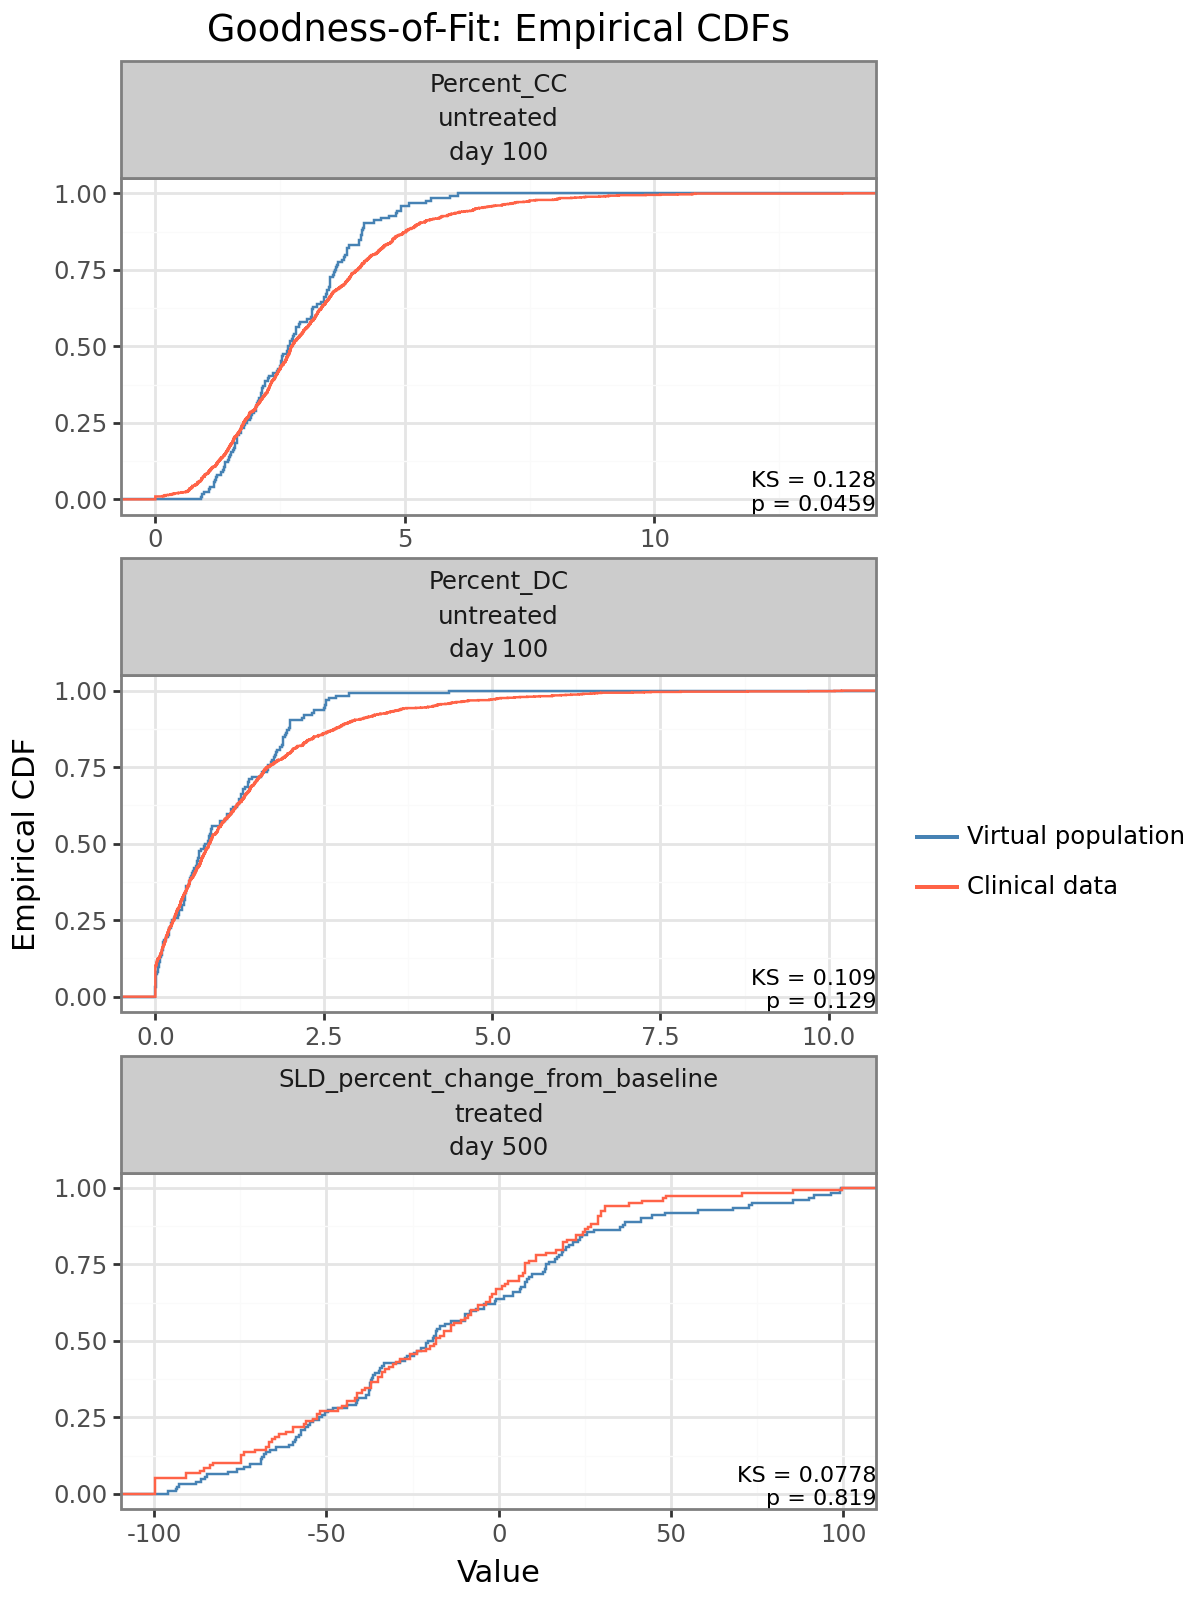

In [16]:
(
    p9.ggplot()
    + p9.stat_ecdf(data=results, mapping=p9.aes(x='value', color='"Virtual population"'))
    + p9.stat_ecdf(data=measurements, mapping=p9.aes(x='measurement', color='"Clinical data"'))
    + p9.geom_text(
        data=ks_table,
        mapping=p9.aes(label='stat_label'),
        ha='right', va='bottom', x=math.inf, y=-math.inf, size=8
    )
    + p9.scale_color_manual(values={"Virtual population": "steelblue", "Clinical data": "tomato"})
    + p9.facet_wrap(
        '~ output + group + time',
        scales='free_x', ncol=1,
        labeller=p9.labeller(time=lambda t: f"day {float(t):.3g}")
    )
    + p9.labs(x='Value', y='Empirical CDF', color='', title='Goodness-of-Fit: Empirical CDFs')
    + p9.theme_bw()
    + p9.theme(figure_size=[6, 8])
)

### 5.4 RECIST Response Categories

RECIST 1.1 defines three response categories based on %SLD change from baseline:

| Category | %SLD change |
|----------|------------|
| Objective Response (OR) | < −30% |
| Stable Disease (SD) | −30% to +20% |
| Progressive Disease (PD) | > +20% |

We compare the frequency of each category in the virtual trial against the KEYNOTE-001 trial using a chi-square test.

In [17]:
def get_recist(sld_values):
    """Classify SLD percent changes into RECIST 1.1 categories."""
    return pd.DataFrame({
        'recist': pd.cut(
            sld_values,
            bins=[-np.inf, -30, 20, np.inf],
            labels=['OR', 'SD', 'PD']
        )
    })

treated_filter = 'group == "treated" and output == "SLD_percent_change_from_baseline"'

vpop_recists = get_recist(results.query(treated_filter)['value'])
meas_recists = get_recist(measurements.query(treated_filter)['measurement'])

recists = pd.concat([
    vpop_recists.assign(source="Virtual trial"),
    meas_recists.assign(source="KEYNOTE-001")
], ignore_index=True)

# Chi-square test
vpop_counts = vpop_recists['recist'].value_counts().sort_index()
expected_counts = meas_recists['recist'].value_counts(normalize=True).sort_index() * vpop_counts.sum()
chi_result = chisquare(vpop_counts, expected_counts)

print(f"Chi-square statistic: {chi_result.statistic:.3g}")
print(f"p-value:              {chi_result.pvalue:.3g}")

Chi-square statistic: 0.662
p-value:              0.718


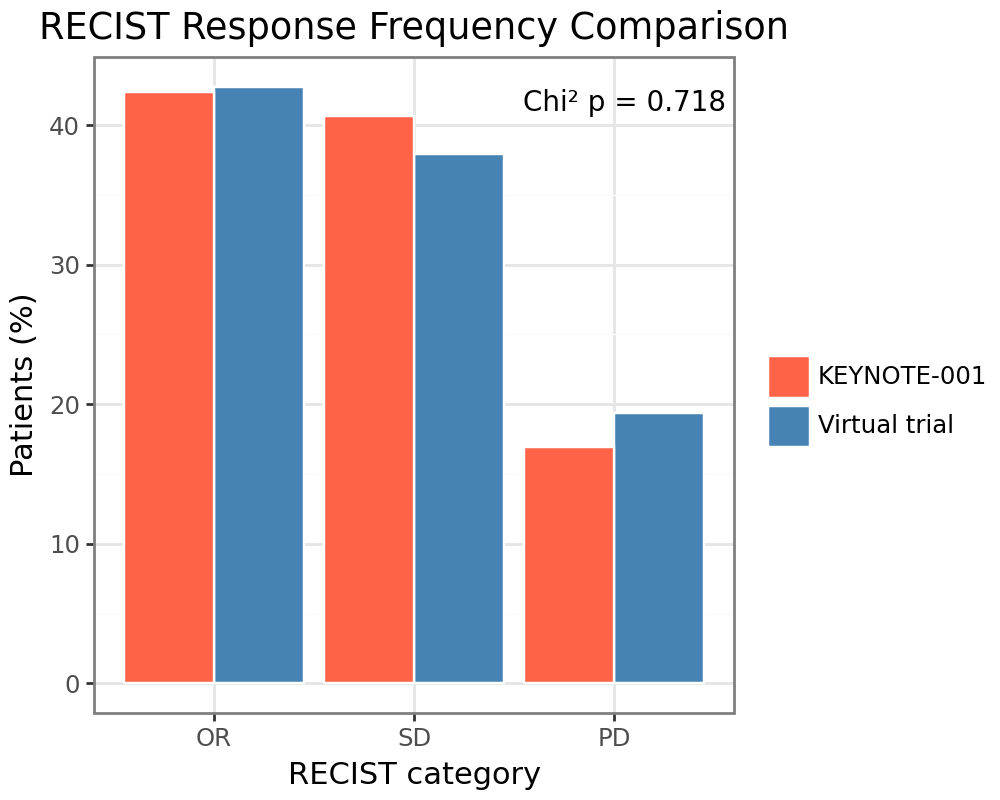

In [18]:
(
    p9.ggplot(data=recists, mapping=p9.aes(x='recist', y=p9.after_stat('100 * prop'), fill='source', group='source'))
    + p9.geom_bar(position='dodge', color='white')
    + p9.annotate(
        geom='text',
        x=np.inf, y=np.inf,
        label=f"\nChi² p = {chi_result.pvalue:.3g} ",
        ha='right', va='top', size=10
    )
    + p9.scale_fill_manual(values={"Virtual trial": "steelblue", "KEYNOTE-001": "tomato"})
    + p9.labs(
        x='RECIST category', y='Patients (%)',
        fill='', title='RECIST Response Frequency Comparison'
    )
    + p9.theme_bw()
    + p9.theme(figure_size=[5, 4])
)

### 5.5 Waterfall Plot Comparison

A side-by-side waterfall plot shows the distribution of individual patient responses across the actual and virtual trials.

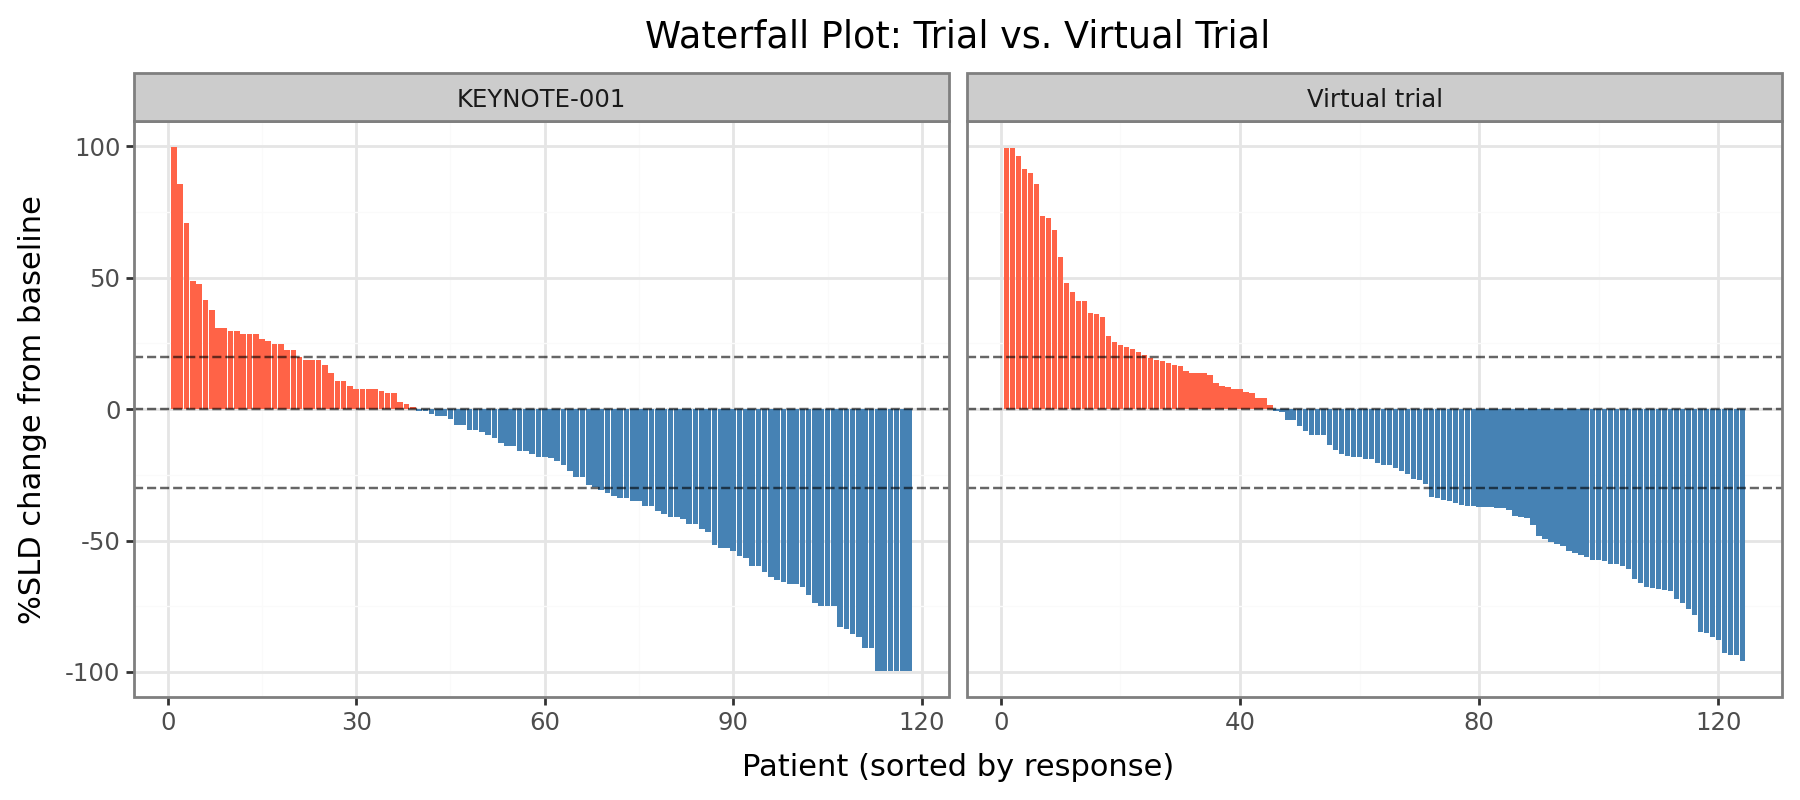

In [19]:
waterfall_data = pd.concat([
    sld_changes[['measurement']].rename(columns={'measurement': 'value'}).assign(source='KEYNOTE-001'),
    results.query(treated_filter)[['value']].assign(source='Virtual trial')
], ignore_index=True)

waterfall_data['patient_rank'] = waterfall_data.groupby('source').value.rank(method='first', ascending=False)

(
    p9.ggplot(data=waterfall_data)
    + p9.geom_col(
        mapping=p9.aes(
            x='patient_rank',
            y='value',
            fill='value < 0'
        )
    )
    + p9.geom_hline(yintercept=[-30, 0, 20], linetype='dashed', color='black', alpha=0.6)
    + p9.scale_fill_manual(values={True: 'steelblue', False: 'tomato'}, guide=None)
    + p9.facet_wrap('~ source', scales='free_x', ncol=2)
    + p9.labs(
        x='Patient (sorted by response)',
        y='%SLD change from baseline',
        title='Waterfall Plot: Trial vs. Virtual Trial'
    )
    + p9.theme_bw()
    + p9.theme(figure_size=[9, 4])
)

## 6. Full Time-Course Re-simulation

The VPop inference evaluated outcomes only at the clinical assessment endpoints. Here we re-simulate the complete time course over 500 days to visualize the dynamic trajectories of each virtual patient under treated and untreated conditions.

The call uses `abm.linspace()` to generate a dense, evenly-spaced time grid and requests several model outputs beyond the endpoints used in inference.

In [20]:
output_times = abm.linspace(0, 500, 501, 'd')

simres = abm.simulate(
    models="inputs/CIC_v4.2.0.iqd",
    times=output_times,
    simulations=vpop_simulations,
    parameters=vpop_parameters,
    outputs=['TME', 'SLD_percent_change_from_baseline', 'antiPD1_Central'],
).to_pandas(tall_outputs=True)

print(f"Simulation result: {len(simres):,} rows  ({simres['fit_id'].nunique()} patients × {simres['group'].nunique()} groups)")

Total: 0, Running: 0, Succeeded: 0, Failed: 0

Simulation result: 372,744 rows  (124 patients × 2 groups)


### 6.1 Visualize VPop Trajectories

Each line represents one virtual patient. Panels show treated (Pembrolizumab 10 mg/kg Q3W) and untreated groups side by side.

- **TME** (log scale): Tumor volume dynamics — treated responders show marked reduction; untreated subjects progress uniformly.
- **%SLD change**: Clinical response metric; the ±30% and +20% RECIST thresholds are shown.
- **Anti-PD1 central concentration**: Drug exposure over the dosing schedule.

In [21]:
def timecourse_plot(output, ylabel, **extra_layers):
    """Create a faceted time-course plot for a given model output."""
    plot = (
        p9.ggplot(simres.query('output == @output'), p9.aes('t', 'value', group='fit_id'))
        + p9.geom_line(alpha=0.25, size=0.4)
        + p9.facet_wrap('~ group', scales='free_y',
                        labeller={'treated': 'Treated (Pembro 10 mg/kg Q3W)', 'untreated': 'Untreated'})
        + p9.labs(x='Time (days)', y=ylabel)
        + p9.theme_bw()
        + p9.theme(figure_size=[8, 3])
    )
    return plot

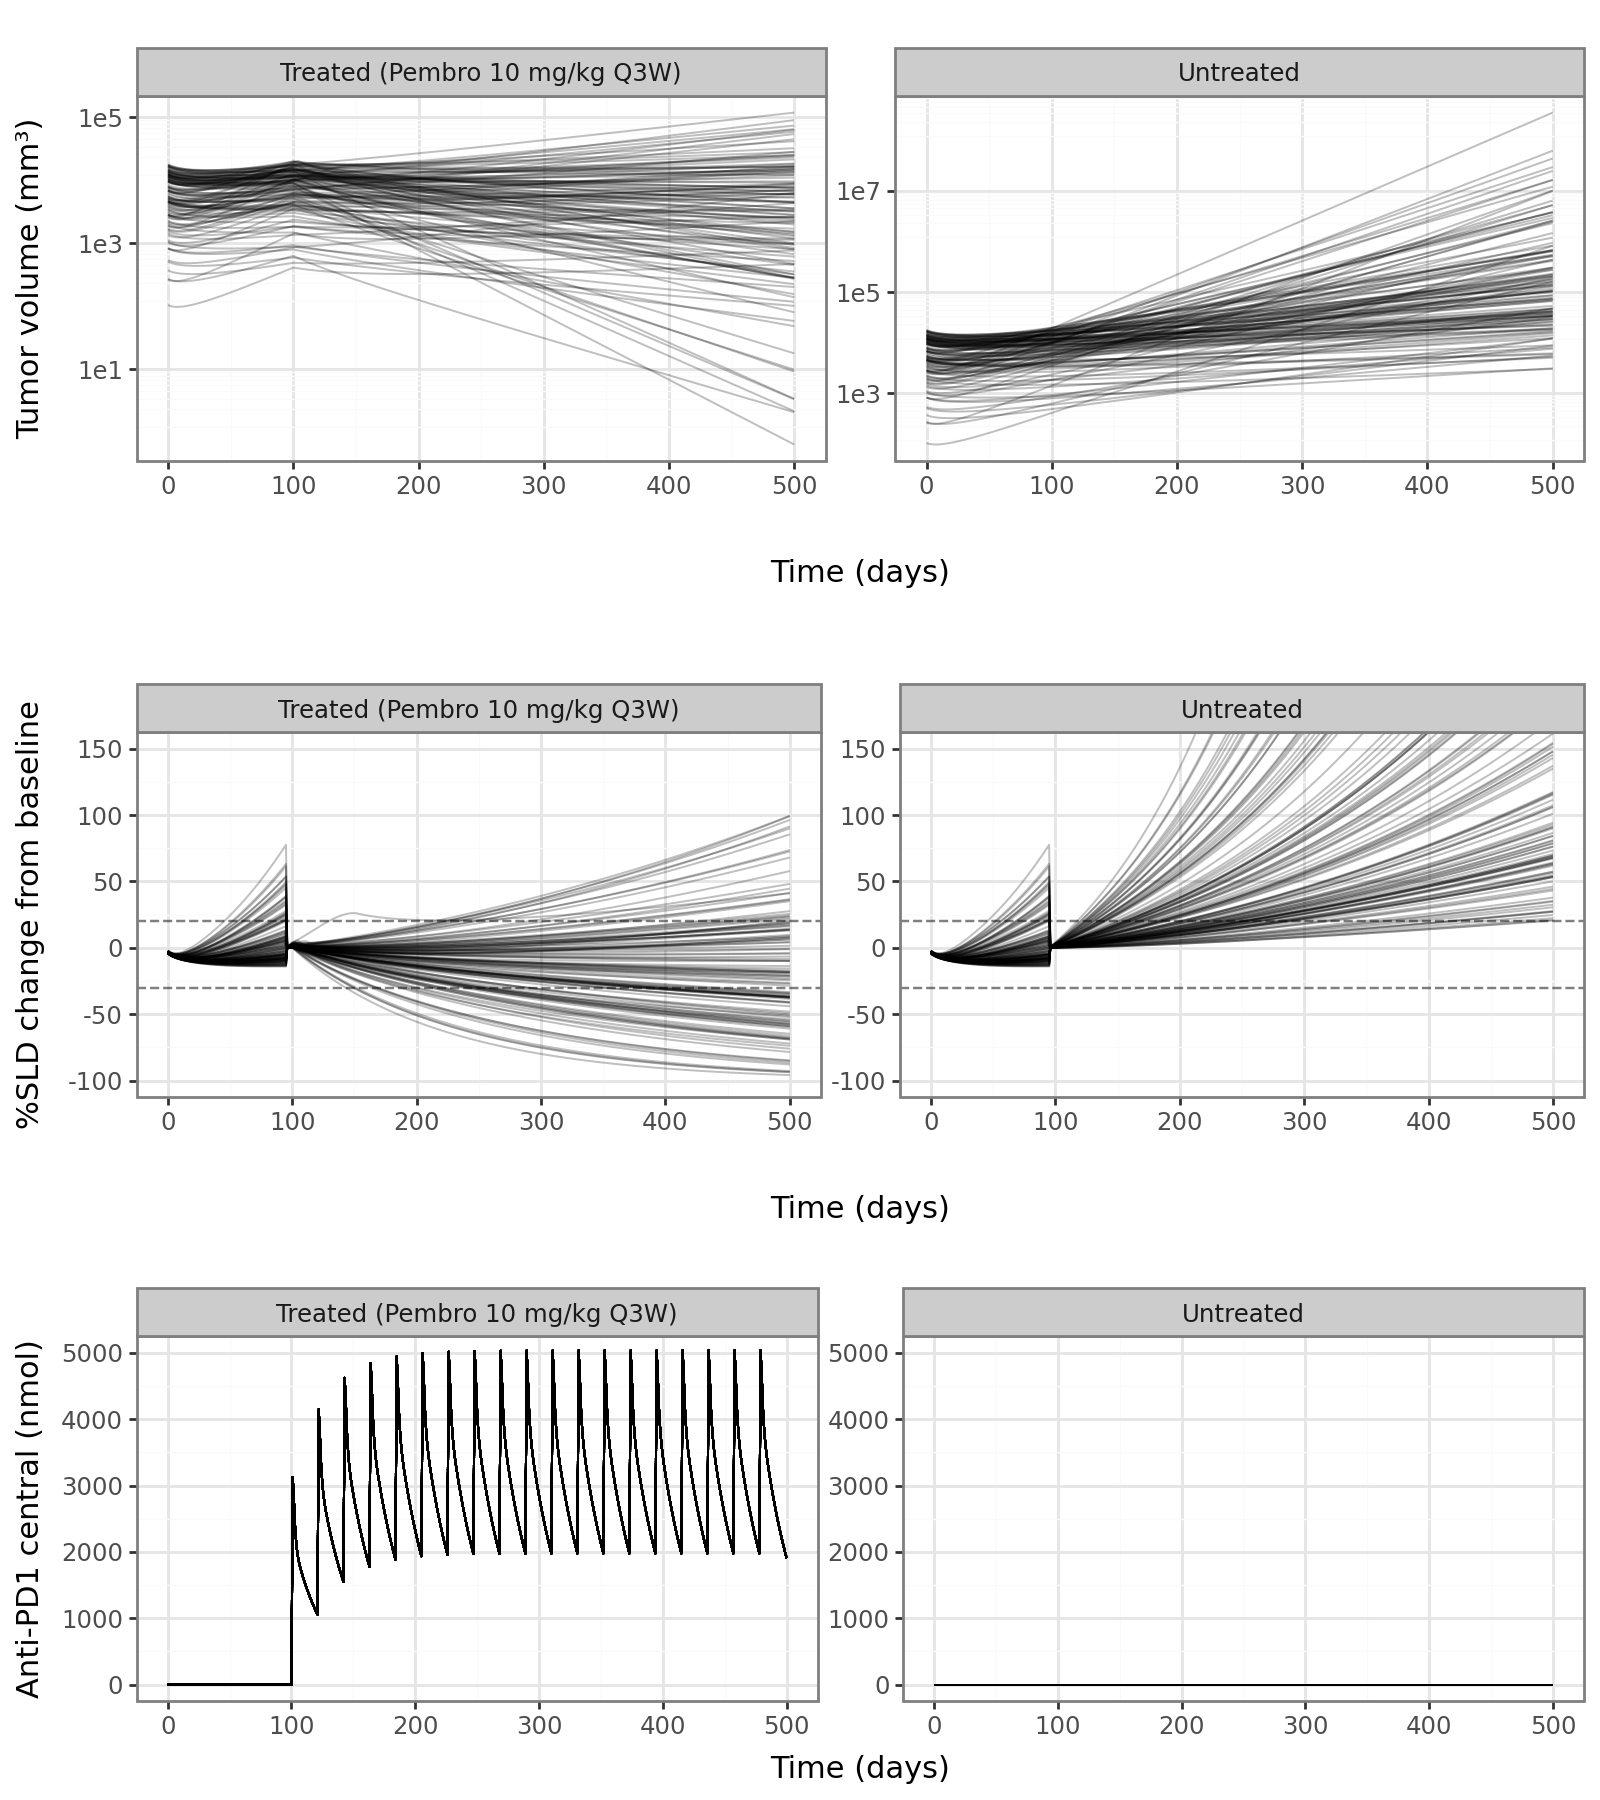

In [22]:
plot_tme = (
    timecourse_plot('TME', ylabel='Tumor volume (mm³)')
    + p9.scale_y_log10()
)

plot_sld = (
    timecourse_plot('SLD_percent_change_from_baseline', ylabel='%SLD change from baseline')
    + p9.geom_hline(yintercept=[-30, 20], linetype='dashed', color='black', alpha=0.5)
    + p9.coord_cartesian(ylim=[-100, 150])
)

plot_drug = (
    timecourse_plot('antiPD1_Central', ylabel='Anti-PD1 central (nmol)')
    + p9.coord_cartesian(ylim=[0, 5000])
)

(plot_tme / plot_sld / plot_drug) + p9.theme(figure_size=[8, 9])

## 7. Export VPop for IQ Design

IQ Design can load a virtual population from a CSV file in **wide format**: each row is one virtual patient, and each column is a model parameter or initial condition.

The `vpop_parameters` table from `virtual_population_tables()` is in tall format (one row per parameter per patient). The code below pivots it to wide format and saves it as `Calibrated_VPop.csv`.

**After saving**, follow these steps to use the file in IQ Design:
1. The file appears in the **Outputs** tab of the notebook
2. Select the file and choose **Export to Project** to make it available in the File Manager
3. In IQ Design, load `Calibrated_VPop.csv` as the virtual population input for virtual trial simulations

In [23]:
vpop_parameters_wide = (
    vpop_parameters
    .query('fit_id != "*"')             # exclude group-level shared rows
    .pivot(columns='parameter', index='fit_id', values='value')
    .rename_axis(columns=None)
    .reset_index()
    .rename(columns={'fit_id': 'ID'})
)

print(f"Wide-format VPop: {vpop_parameters_wide.shape[0]} patients × {vpop_parameters_wide.shape[1] - 1} parameters")
vpop_parameters_wide.head()

Wide-format VPop: 124 patients × 5 parameters


,ID,APC_max,Tc_max,V0,kkill,mu
0,26,1.279222,2.728525,5000.959636,0.748473,0.043696
1,45,0.448593,2.822322,15355.130976,0.108444,0.027984
2,52,4.372040,1.717258,17289.805363,0.653556,0.029508
3,113,0.231090,6.381957,1768.240896,0.325780,0.047718
4,175,1.391992,0.916584,18593.637672,0.262096,0.025850


In [24]:
vpop_parameters_wide.to_csv('Calibrated_VPop.csv', index=False)
print("Saved: Calibrated_VPop.csv")

Saved: Calibrated_VPop.csv
